---
title: "Collocating Geostationary and Polar-Orbiting Satellite Observations" 
subtitle: "This notebook demonstrates how to collocate observations from geostationary and polar-orbiting satellites using DEFAIR tools."
author: "Author: Erwan Fassot (Oxidian)"
tags: [DEFAIR,EUMETSAT,MSG SEVIRI, Metop AVHRR, Sentinel-3 SLSTR, AI Ready Data Generation]
thumbnail: img/EUMETSAT_TEST.png 
license: MIT
copyright: "© 2026 EUMETSAT"
---

<!-- Optional: Add a JupyterHub launch link here. If you don’t have one, you can remove this block. -->

<div style="margin: 6px 0;">
  <a href="https://jupyter.central.data.destination-earth.eu/user-redirect/lab/tree/template1.ipynb" target="_blank" style="text-decoration: none;">
    <span class="launch">🚀 Launch in JupyterHub</span>
  </a>
</div>


# Collocating Geostationary and Polar-Orbiting Satellite Observations




## Contents
A geostationary imager continuously observes the same Earth disc, while a polar-orbiting sensor acquires data along a moving swath, at different times and on a different spatial grid. Combining these observations requires identifying corresponding pixels and accounting for their temporal mismatch.

This notebook demonstrates how to collocate observations acquired by geostationary and polar-orbiting satellites using DEFAIR. Because these instruments observe the Earth with different viewing geometries, spatial resolutions, and acquisition times, combining their measurements requires both spatial and temporal alignment. The notebook walks through a practical workflow using MSG SEVIRI, Metop AVHRR, and Sentinel-3 SLSTR brightness temperature observations, illustrating how to reproject data onto common grids, analyse temporal differences between acquisitions, and generate collocated datasets suitable for further analysis. 

### Objective

The primary goal of this notebook is to demonstrate how to spatially and temporally collocate observations from geostationary and low-Earth-orbit (LEO) satellite instruments. Users will learn how to align datasets onto common reference grids, compare measurements from different sensors, and create analysis-ready outputs for multi-sensor applications. 

### Data Sources

The notebook uses sample datasets stored in object storage and accessed through DEFAIR:

- MSG SEVIRI Level 1.5 brightness temperature observations (`IR_108` channel).
- Metop AVHRR Level 1B brightness temperature observations (`brightness_temperature_4`).
- Sentinel-3 SLSTR radiance and brightness temperature observations.

The sample datasets used throughout this notebook are available from the DestinE demonstration data repository:
https://s3.central.data.destination-earth.eu/swift/v1/datalake-demo-data/

### Methods

The workflow includes the following steps:

1. Read and subset geostationary and polar-orbiting satellite data.
2. Explore the temporal characteristics of the observations and assess acquisition-time differences.
3. Reproject datasets onto a common geographic coordinate system (EPSG:4326).
4. Perform spatial collocation using DEFAIR alignment transformations.
5. Compare observations from multiple sensors on shared grids.
6. Extend the collocation workflow to include Sentinel-3 SLSTR data.
7. Export the resulting collocated data cube in Zarr format for downstream analysis. 

### Prerequisites

Before running this notebook, ensure that the DEFAIR packages are installed and available in your execution environment.

- Running on Insula Code
    - A valid [Destination Earth (DestinE)](https://platform.destine.eu/) user account is required.
    - Select the **`defair`** kernel before executing the notebook.
- Running on DEDL JupyterHub
    - A valid [Destination Earth (DestinE)](https://platform.destine.eu/) user account is required.
    - Access to [EDGE Services](https://application.data.destination-earth.eu/) is required.
    - Select the **`Python (defair)`** kernel before executing the notebook.
- Running Locally
    - Follow the instructions to [install DEFAIR locally](https://cloudferro-dedl-staging.readthedocs-hosted.com/en/latest/working_with_ai_in_the_data_lake/defair-01-10-2026/installation/installation.html#install-defair-locally).
    - Launch a local JupyterLab environment with access to the DEFAIR installation.
    - Ensure all required dependencies are installed before running the notebook.

### Expected Output

At the end of this notebook, users will obtain:

- Visual comparisons of satellite observations before and after collocation.
- A common spatial grid containing observations from multiple sensors.
- Examples of collocated SEVIRI, AVHRR, and SLSTR brightness temperature datasets.
- An analysis-ready data cube exported in Zarr format for further processing and applications. 

## Imports

The full-disc collocation example near the end of the notebook requires approximately 75 seconds and 4 GB of memory. To support this workflow, the first cell starts a single-worker Dask client with a 12 GB memory limit.

In [1]:
from pathlib import Path

import numpy as np
import xarray as xr

from defair_data.core import Dataset
from defair_data.dask_manager import get_dask_client, close_dask_client
from defair.notebook_helpers import viz

viz.quiet()
viz.load_env()
get_dask_client(n_workers=1, threads_per_worker=4, memory_limit="12GB", processes=False)
OUTPUT = Path("output"); OUTPUT.mkdir(exist_ok=True)

ROOT = "s3://datalake-demo-data/defair-notebook-data"
MSG_PATH = f"{ROOT}/msg-seviri-l15/msg_f997b2b630fc42_MSG3-SEVI-MSG15-0100-NA-20251210102744.394000000Z-NA.nat"
AVHRR_PATH = f"{ROOT}/metop-avhrr-l1b/AVHR_xxx_1B_M01_20251210101003Z_20251210114903Z_N_O_20251210105813Z"
SLSTR_PATH = f"{ROOT}/sentinel3-slstr-rbt/S3B_SL_1_RBT____20251210T102103_20251210T102403_20251211T151934_0179_114_179_2700_MAR_O_NT_004.SEN3"

# Study box over the eastern Atlantic and north-west Africa (lon_min, lon_max,
# lat_min, lat_max). The Metop-B pass crosses it while SEVIRI is scanning it.
BOX = (-35.0, 5.0, -10.0, 42.0)

ImportError: defair.notebook_helpers needs cartopy and matplotlib. Install the defair[visualization] extra, or from a defair-core checkout run: uv sync --frozen --package defair --package defair-data --package defair-ops --package defair-api --group notebooks

## Read both instruments

Two readers, two grids, one call each.

In [6]:
# The whole disc and the whole orbit are kept: the last section goes back to them uncropped,
# and reading a granule again costs as much as the first read.
msg_disc = Dataset.from_source(
    MSG_PATH,
    reader="msg15nat",
    source="s3",
    channels=["IR_108"],
    use_channel_names=True,
    calibration="brightness_temperature", source_kwargs={"anon": True, "endpoint_url": "https://s3.central.data.destination-earth.eu"}
)
avhrr_orbit = Dataset.from_source(
    AVHRR_PATH,
    reader="metop_avhrrl1",
    source="s3",
    bands=["brightness_temperature_4", "latitude", "longitude"],source_kwargs={"anon": True, "endpoint_url": "https://s3.central.data.destination-earth.eu"}
).transform("content_filter", include_vars=["brightness_temperature_4"])

msg = msg_disc.transform("spatial_filter", lon_min=BOX[0], lon_max=BOX[1], lat_min=BOX[2], lat_max=BOX[3])
avhrr = avhrr_orbit.transform("spatial_filter", lon_min=BOX[0], lon_max=BOX[1], lat_min=BOX[2], lat_max=BOX[3])

for label, ds in [("SEVIRI", msg), ("AVHRR", avhrr)]:
    print(f"  {label:6s} dims={dict(ds.data.sizes)}  vars={list(ds.data.data_vars)}")

  SEVIRI dims={'time': 1, 'y': 1713, 'x': 1363, 'bnds': 2}  vars=['IR_108', 'geostationary']
  AVHRR  dims={'time': 1, 'y': 5968, 'x': 2048, 'bnds': 2}  vars=['brightness_temperature_4']


shared display range: 227.9 to 306.5 K


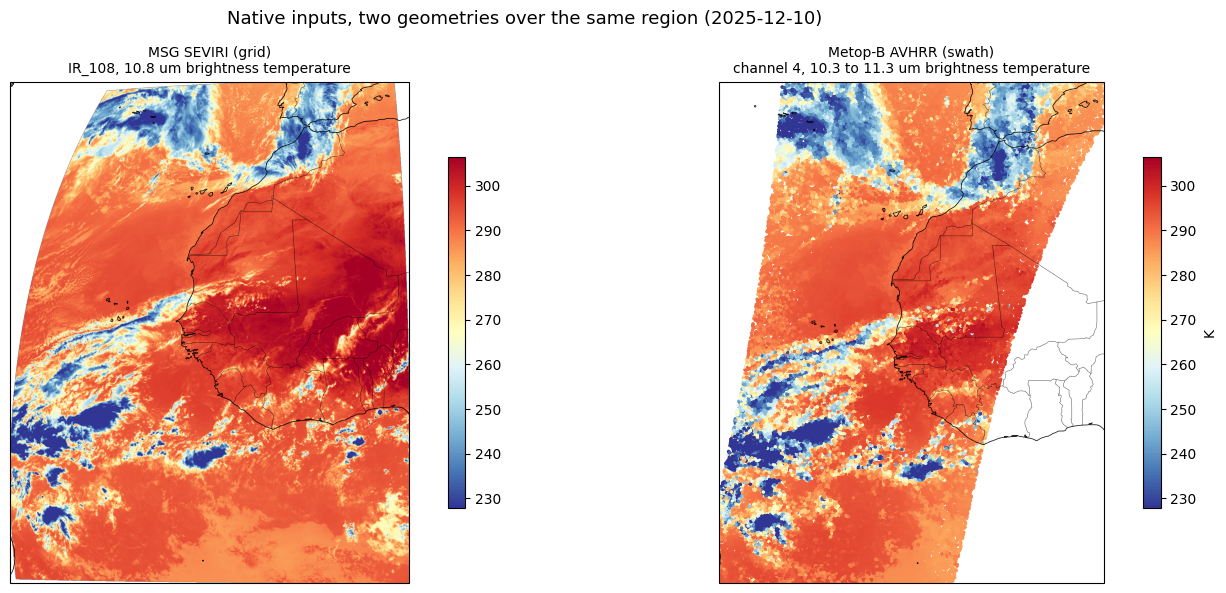

In [7]:
# One colour range for every comparison in this tutorial, taken from the geostationary
# field. Letting each panel autoscale its own spread draws the same brightness temperature
# in a different colour on each side of a comparison, which is the one thing a collocation
# figure must not do. Every instrument here measures the same 10.8 um window, so one range
# fits them all.
BT_RANGE = viz.vrange(msg.data["IR_108"].isel(time=0).values)
print(f"shared display range: {BT_RANGE[0]:.1f} to {BT_RANGE[1]:.1f} K")

viz.show_panels(
    [
        {"ds": msg, "var": "IR_108", "kind": "grid", "cmap": "RdYlBu_r",
         "title": "MSG SEVIRI (grid)\nIR_108, 10.8 um brightness temperature",
         "vmin": BT_RANGE[0], "vmax": BT_RANGE[1]},
        {"ds": avhrr, "var": "brightness_temperature_4", "kind": "swath", "cmap": "RdYlBu_r",
         "title": "Metop-B AVHRR (swath)\nchannel 4, 10.3 to 11.3 um brightness temperature",
         "label": "K", "extent": [BOX[0], BOX[1], BOX[2], BOX[3]],
         "vmin": BT_RANGE[0], "vmax": BT_RANGE[1]},
    ],
    suptitle="Native inputs, two geometries over the same region (2025-12-10)",
    save=OUTPUT / "geo_leo_native.png",
    figsize=(15, 6),
)

## What "at the same time" means here

The geostationary granule has one timestamp for the repeat cycle. The polar granule has a
timestamp per scanline. Collocation cannot make those identical, and the cube keeps
neither pair: temporal matching works on the granule-level `time` coordinate, and with
`time_bounds="base"` the output carries the SEVIRI slot alone. The per-scanline times are
indexed by the swath's own spatial dimension, so resampling onto the target grid drops
them. The cell below is where the two granule labels are visible, before that happens.

In [8]:
msg_time = msg.data["time"].values[0]
avhrr_time = avhrr.data["time"].values[0]
scanline_times = avhrr.data["time_mdr"].values
offset_s = (msg_time - avhrr_time) / np.timedelta64(1, "s")

print(f"SEVIRI repeat cycle nominal start : {msg_time}")
print(f"AVHRR granule sensing start       : {avhrr_time}")
print(f"gap between the granule labels    : {offset_s:.0f} s")
print(f"AVHRR scanlines in the crop span  : {scanline_times.min()} -> {scanline_times.max()}")
print(f"SEVIRI slot inside that span      : {scanline_times.min() < msg_time < scanline_times.max()}")

SEVIRI repeat cycle nominal start : 2025-12-10T10:15:00.000000000
AVHRR granule sensing start       : 2025-12-10T10:10:03.000000000
gap between the granule labels    : 297 s
AVHRR scanlines in the crop span  : 2025-12-10T10:13:04.418000000 -> 2025-12-10T10:29:38.918000000
SEVIRI slot inside that span      : True


## Align the swath onto a shared grid

`alignment` takes a reference dataset and puts the others onto its grid.

In [9]:
cube = msg.transform(
    "alignment",
    datasets=[avhrr],
    target="EPSG:4326",
    target_resolution=0.05,
    spatial_method="nearest",
    temporal_method="nearest",
    time_tolerance="10min",
    time_bounds="base",
    bounds_mode="intersection",
)

MSG_VAR = "msg_seviri_native_format_IR_108"
AVHRR_VAR = "ds1_brightness_temperature_4"

print("Collocated cube:")
print(f"  dims      : {dict(cube.data.sizes)}")
print(f"  variables : {list(cube.data.data_vars)}")
for name in (MSG_VAR, AVHRR_VAR):
    field = np.asarray(cube.data[name].isel(time=0).values, dtype=float)
    finite = field[np.isfinite(field)]
    print(
        f"  {name:34s} covers {np.isfinite(field).mean():6.1%} of the grid, "
        f"{finite.min():.1f} to {finite.max():.1f} K"
    )

2026-09-29 10:26:08.840 | WARNING  | defair_ops.transformations.reprojection.backends.rioxarray_backend:_reproject_single_variable:1525 - Variable 'geostationary' is not reprojectable, skipping
2026-09-29 10:26:08.846 | WARNING  | defair_ops.transformations.alignment.alignment_plugin:_align_temporal:620 - Dropped the 'time' bounds declaration and its variable 'time_bnds': the source's cells describe the axis it was read on, not the one it has been aligned onto.
2026-09-29 10:28:29.136 | WARNING  | defair_ops.transformations.alignment.alignment_plugin:_align_temporal:620 - Dropped the 'time' bounds declaration and its variable 'time_bnds': the source's cells describe the axis it was read on, not the one it has been aligned onto.


Collocated cube:
  dims      : {'time': 1, 'lon': 800, 'lat': 1040}
  variables : ['msg_seviri_native_format_IR_108', 'ds1_brightness_temperature_4']
  msg_seviri_native_format_IR_108    covers 100.0% of the grid, 194.1 to 314.7 K
  ds1_brightness_temperature_4       covers  71.3% of the grid, 195.4 to 305.5 K


  msg_seviri_native_format_IR_108    covers 100.0% of the grid, 194.1 to 314.7 K


  ds1_brightness_temperature_4       covers  71.3% of the grid, 195.4 to 305.5 K


2026-09-29 10:30:57.560 | WARNING  | defair_ops.transformations.reprojection.backends.base:_dims_from_cdm:255 - Multiple GriddedModels match (height=1040, width=800): ['msg_seviri_native_format_reproject_output', 'ds1_reproject_output']; picking 'msg_seviri_native_format_reproject_output'. Call `dataset.select_grid(<id>)` before alignment to disambiguate.
2026-09-29 10:31:01.909 | WARNING  | defair_ops.transformations.reprojection.backends.base:_dims_from_cdm:255 - Multiple GriddedModels match (height=1040, width=800): ['msg_seviri_native_format_reproject_output', 'ds1_reproject_output']; picking 'msg_seviri_native_format_reproject_output'. Call `dataset.select_grid(<id>)` before alignment to disambiguate.


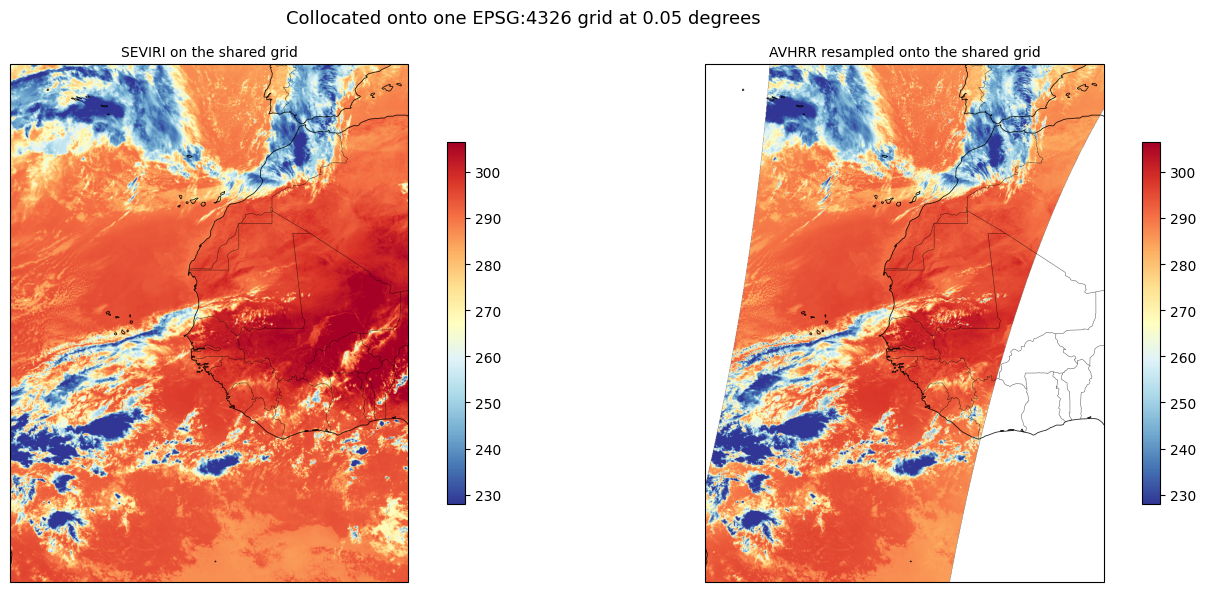

In [10]:
viz.show_panels(
    [
        {"ds": cube, "var": MSG_VAR, "kind": "grid", "cmap": "RdYlBu_r",
         "title": "SEVIRI on the shared grid",
         "vmin": BT_RANGE[0], "vmax": BT_RANGE[1]},
        {"ds": cube, "var": AVHRR_VAR, "kind": "grid", "cmap": "RdYlBu_r",
         "title": "AVHRR resampled onto the shared grid",
         "vmin": BT_RANGE[0], "vmax": BT_RANGE[1]},
    ],
    suptitle="Collocated onto one EPSG:4326 grid at 0.05 degrees",
    save=OUTPUT / "geo_leo_cube_epsg4326.png",
    figsize=(15, 6),
)

## Keeping the reference product's own grid

The section above put both products on a common EPSG:4326 target. Naming a reference dataset
instead keeps that product's native grid and resamples the others onto it, so the SEVIRI
pixels come back untouched. The choice belongs to whoever knows which grid the downstream
work needs.

2026-09-29 10:31:19.324 | WARNING  | defair_ops.transformations.reprojection.backends.rioxarray_backend:_reproject_single_variable:1525 - Variable 'geostationary' is not reprojectable, skipping
2026-09-29 10:31:19.327 | WARNING  | defair_ops.transformations.alignment.alignment_plugin:_align_temporal:620 - Dropped the 'time' bounds declaration and its variable 'time_bnds': the source's cells describe the axis it was read on, not the one it has been aligned onto.
2026-09-29 10:31:57.119 | WARNING  | defair_ops.transformations.alignment.alignment_plugin:_align_temporal:620 - Dropped the 'time' bounds declaration and its variable 'time_bnds': the source's cells describe the axis it was read on, not the one it has been aligned onto.
2026-09-29 10:31:57.123 | WARNING  | defair_ops.transformations.reprojection.backends.base:_dims_from_cdm:255 - Multiple GriddedModels match (height=1713, width=1363): ['msg_seviri_native_format_reproject_output', 'ds1_reproject_output']; picking 'msg_seviri_nat

  dims      : {'time': 1, 'x': 1363, 'y': 1713}
  variables : ['msg_seviri_native_format_IR_108', 'ds1_brightness_temperature_4']
  grid kept : x and y identical to the SEVIRI input -> True


2026-09-29 10:32:00.404 | WARNING  | defair_ops.transformations.reprojection.backends.base:_dims_from_cdm:255 - Multiple GriddedModels match (height=1713, width=1363): ['msg_seviri_native_format_reproject_output', 'ds1_reproject_output']; picking 'msg_seviri_native_format_reproject_output'. Call `dataset.select_grid(<id>)` before alignment to disambiguate.


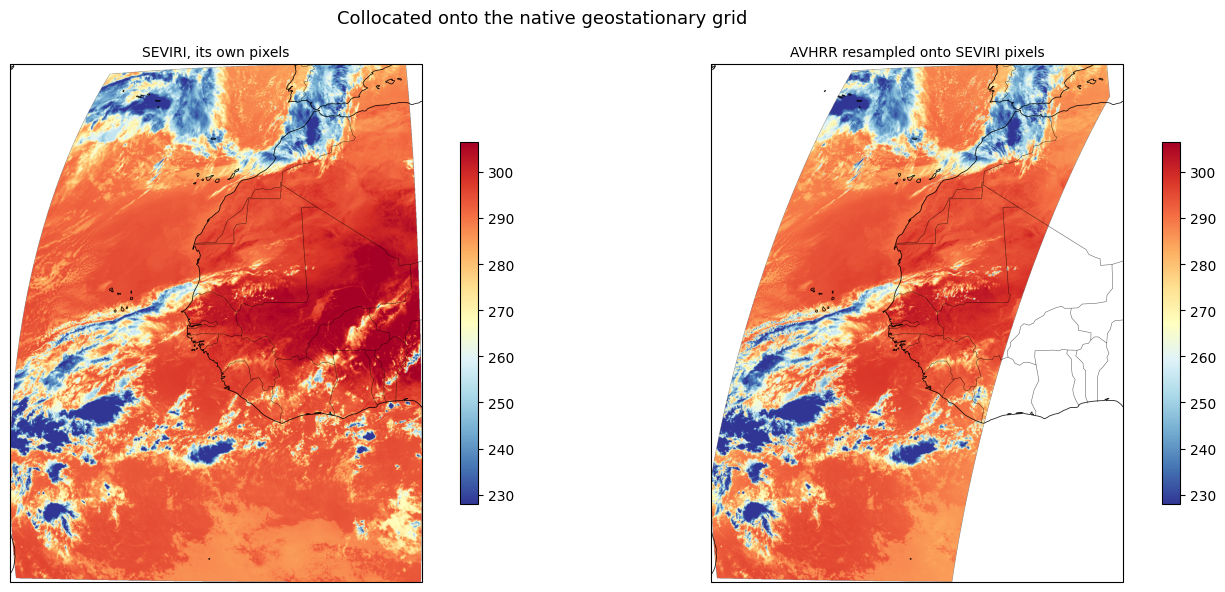

In [11]:
cube_geos = msg.transform(
    "alignment",
    datasets=[avhrr],
    reference_dataset=msg,
    spatial_method="nearest",
    temporal_method="nearest",
    time_tolerance="10min",
    time_bounds="base",
)

print(f"  dims      : {dict(cube_geos.data.sizes)}")
print(f"  variables : {list(cube_geos.data.data_vars)}")
print(f"  grid kept : x and y identical to the SEVIRI input -> "
      f"{np.array_equal(cube_geos.data['x'].values, msg.data['x'].values)}")

viz.show_panels(
    [
        {"ds": cube_geos, "var": MSG_VAR, "kind": "grid", "cmap": "RdYlBu_r",
         "title": "SEVIRI, its own pixels",
         "vmin": BT_RANGE[0], "vmax": BT_RANGE[1]},
        {"ds": cube_geos, "var": AVHRR_VAR, "kind": "grid", "cmap": "RdYlBu_r",
         "title": "AVHRR resampled onto SEVIRI pixels",
         "vmin": BT_RANGE[0], "vmax": BT_RANGE[1]},
    ],
    suptitle="Collocated onto the native geostationary grid",
    save=OUTPUT / "geo_leo_cube_geostationary.png",
    figsize=(15, 6),
)

## Three instruments, one grid

Sentinel-3B's SLSTR crossed the same box at 10:21 UTC, six minutes after the SEVIRI slot and
inside the 10:13 to 10:29 window the Metop-B scanlines cover it. It is a polar swath like
AVHRR, but a conical scanner on its own infrared grid, so it arrives with a third layout
again. `alignment` takes a list of datasets, so a third instrument is one more entry.

The read prints the SLSTR reader's own metadata notices, which are about the product's flag
declarations rather than its data, and one notice worth reading: `Could not determine bounds
for dataset 2`. The granule carries finite 2-D `latitude` and `longitude`, so it does have an
extent to offer, and the message reports how `alignment` looks for one rather than a property
of a conical scan. Its bounds discovery asks `rio.bounds()` first; that call raises
whenever the spatial dimensions carry no 1-D coordinates of their own, which is what `rows`
and `columns` are here, and the 2-D coordinates are never consulted afterwards. AVHRR escapes the same gap only because `spatial_filter` stamped its own bounds
onto that dataset earlier. So `bounds_mode="intersection"` intersects the two datasets whose
bounds it could read, which is why the cube below keeps the same 800 by 1040 grid as the
two-source cube above. The SLSTR values are still resampled onto that grid; only its extent is
decided without them.

All three measure a thermal infrared window channel and report brightness temperature in
kelvin, which is what makes the last panel worth drawing. The overlay paints SEVIRI into red,
AVHRR into green and SLSTR into blue on one shared kelvin scale wide enough that nothing
clips, so the colour of a cell says what the three instruments make of it:

- neutral, white through grey, is agreement: all three read the same temperature there;
- a tint is a disagreement, and names the instrument reading warmest;
- a saturated colour is absence rather than disagreement, because a channel with no data at a
  cell contributes nothing to it. The yellow over most of the box is where SLSTR does not
  reach, the red bands down both edges are where the Metop-B swath ends too, and the magenta
  block is the part of the SLSTR scan that falls outside that swath.

That last point is the honest limit of collocating three instruments from one morning. The
region where all three actually saw the same place is the overlap of a disc, a swath and a
scan, which here is the pale strip over Mauritania and Mali, not the whole box.


In [13]:
slstr = Dataset.from_source(SLSTR_PATH, reader="sentinel3_sl_1_rbt", source="s3", grid="in", source_kwargs={"anon": True, "endpoint_url": "https://s3.central.data.destination-earth.eu"}).transform(
    "content_filter", include_vars=["S8_BT_in"]
)

cube3 = msg.transform(
    "alignment",
    datasets=[avhrr, slstr],
    target="EPSG:4326",
    target_resolution=0.05,
    spatial_method="nearest",
    temporal_method="nearest",
    time_tolerance="10min",
    time_bounds="base",
    bounds_mode="intersection",
)

# Each source keeps its own prefix in the cube, so name the panels by substring rather than
# by a prefix this cell would have to guess.
SOURCES = [
    ("IR_108", "MSG SEVIRI"),
    ("brightness_temperature_4", "Metop-B AVHRR"),
    ("S8_BT_in", "Sentinel-3B SLSTR"),
]

print(f"  dims      : {dict(cube3.data.sizes)}")
print(f"  variables : {list(cube3.data.data_vars)}")

extremes = []
for substring, label in SOURCES:
    name, array = viz.pick(cube3, substring)
    field = np.asarray(array.isel(time=0).values, dtype=float)
    finite = field[np.isfinite(field)]
    extremes += [finite.min(), finite.max()]
    print(
        f"  {label:18s} {name:34s} covers {np.isfinite(field).mean():6.1%} of the grid, "
        f"{finite.min():.1f} to {finite.max():.1f} K"
    )

# The overlay needs a range nothing falls outside, because a clipped channel draws two
# different temperatures in the same colour and the panel's whole claim is that colour
# means temperature. The panels keep the percentile stretch above, which has the contrast.
BT_FULL = (min(extremes), max(extremes))
print(f"  overlay range: {BT_FULL[0]:.1f} to {BT_FULL[1]:.1f} K, against {BT_RANGE[0]:.1f} to {BT_RANGE[1]:.1f} K for the panels")


2026-09-29 10:35:49.729 | WARNING  | defair.cf_history_mixin:apply_cf_global_metadata:368 - No CF metadata template for reader 'sentinel3_sl_1_rbt'
2026-09-29 10:35:49.849 | WARNING  | defair_data.cf_flags:_flag_specs:186 - Flag name 'spare' repeats on 'bayes_in'; the later declaration wins
2026-09-29 10:35:49.850 | WARNING  | defair_data.cf_flags:_flag_specs:186 - Flag name 'spare' repeats on 'bayes_in'; the later declaration wins
2026-09-29 10:35:49.904 | WARNING  | defair_data.cf_flags:_flag_specs:186 - Flag name 'spare' repeats on 'bayes_in'; the later declaration wins
2026-09-29 10:35:49.924 | WARNING  | defair_data.cf_flags:_flag_specs:186 - Flag name 'spare' repeats on 'cloud_in'; the later declaration wins
2026-09-29 10:35:50.014 | WARNING  | defair_data.cf_flags:_flag_specs:186 - Flag name 'spare' repeats on 'confidence_in'; the later declaration wins
2026-09-29 10:35:50.140 | WARNING  | defair_ops.transformations.alignment.alignment_plugin:_calculate_common_bounds:804 - Could

  dims      : {'time': 1, 'lon': 800, 'lat': 1040}
  variables : ['msg_seviri_native_format_IR_108', 'ds1_brightness_temperature_4', 'ipf-sl-1_06.22_S8_BT_in']
  MSG SEVIRI         msg_seviri_native_format_IR_108    covers 100.0% of the grid, 194.1 to 314.7 K
  Metop-B AVHRR      ds1_brightness_temperature_4       covers  71.3% of the grid, 195.4 to 305.5 K
  Sentinel-3B SLSTR  ipf-sl-1_06.22_S8_BT_in            covers   7.0% of the grid, 226.5 to 312.3 K
  overlay range: 194.1 to 314.7 K, against 227.9 to 306.5 K for the panels


2026-09-23 11:31:20.149 | WARNING  | defair_ops.transformations.alignment.alignment_plugin:_calculate_common_bounds:804 - Could not determine bounds for dataset 2


2026-09-23 11:31:20.995 | WARNING  | defair_ops.transformations.reprojection.backends.rioxarray_backend:_reproject_single_variable:1525 - Variable 'geostationary' is not reprojectable, skipping


2026-09-23 11:31:21.000 | WARNING  | defair_ops.transformations.alignment.alignment_plugin:_align_temporal:620 - Dropped the 'time' bounds declaration and its variable 'time_bnds': the source's cells describe the axis it was read on, not the one it has been aligned onto.


...

2026-09-23 11:31:44.517 | WARNING  | defair_ops.transformations.alignment.alignment_plugin:_align_temporal:620 - Dropped the 'time' bounds declaration and its variable 'time_bnds': the source's cells describe the axis it was read on, not the one it has been aligned onto.


  dims      : {'time': 1, 'lon': 800, 'lat': 1040}
  variables : ['msg_seviri_native_format_IR_108', 'ds1_brightness_temperature_4', 'ipf-sl-1_06.22_S8_BT_in']


  MSG SEVIRI         msg_seviri_native_format_IR_108    covers 100.0% of the grid, 194.1 to 314.7 K


  Metop-B AVHRR      ds1_brightness_temperature_4       covers  71.3% of the grid, 195.4 to 305.5 K


  Sentinel-3B SLSTR  ipf-sl-1_06.22_S8_BT_in            covers   7.0% of the grid, 226.5 to 312.3 K
  overlay range: 194.1 to 314.7 K, against 227.9 to 306.5 K for the panels


2026-09-29 10:46:06.459 | WARNING  | defair_ops.transformations.reprojection.backends.base:_dims_from_cdm:255 - Multiple GriddedModels match (height=1040, width=800): ['msg_seviri_native_format_reproject_output', 'ds1_reproject_output', 'ipf-sl-1_06.22_reproject_output']; picking 'msg_seviri_native_format_reproject_output'. Call `dataset.select_grid(<id>)` before alignment to disambiguate.


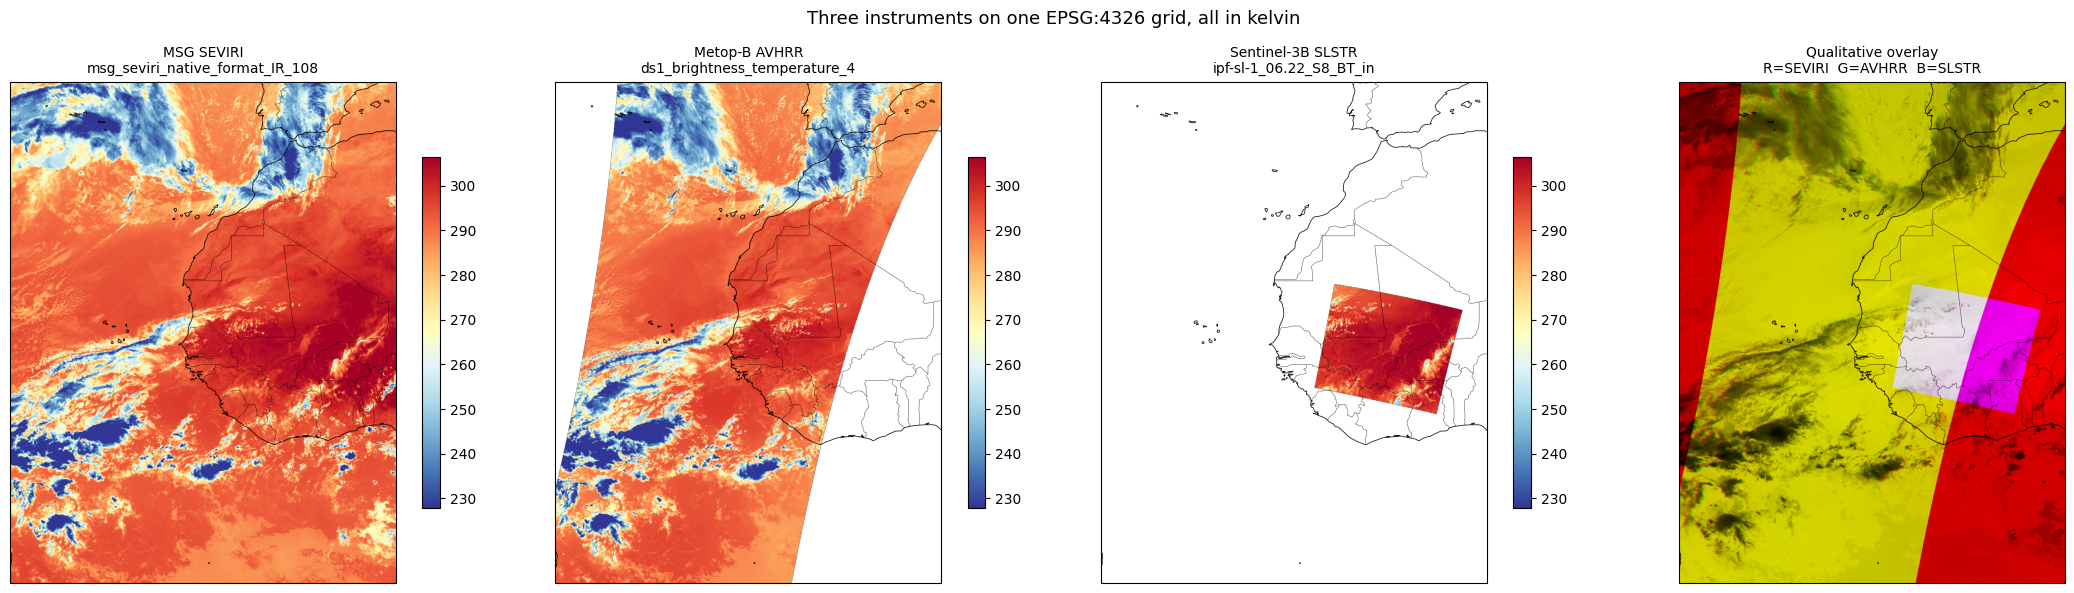

In [14]:
viz.show_collocation_grid(
    cube3,
    panels=[(substring, "RdYlBu_r", label) for substring, label in SOURCES],
    rgb=tuple(substring for substring, _ in SOURCES),
    rgb_title="Qualitative overlay\nR=SEVIRI  G=AVHRR  B=SLSTR",
    rgb_vmin=BT_FULL[0],
    rgb_vmax=BT_FULL[1],
    extent=[BOX[0], BOX[1], BOX[2], BOX[3]],
    suptitle="Three instruments on one EPSG:4326 grid, all in kelvin",
    save=OUTPUT / "geo_leo_three_instruments.png",
    vmin=BT_RANGE[0],
    vmax=BT_RANGE[1],
)


## Tightening the time tolerance

The tolerance decides which granules are close enough in time to be paired, and it compares
the two granule labels rather than the observation times of individual pixels. The cell
above shows the difference that makes: the AVHRR scanlines over the box contain the SEVIRI
slot, so the observations are minutes apart, while the labels are the gap printed there. A
bound shorter than that label gap pairs nothing, so the swath variable survives in the cube
with no values in it. That is the trade made explicit.

In [15]:
cube_strict = msg.transform(
    "alignment",
    datasets=[avhrr],
    target="EPSG:4326",
    target_resolution=0.05,  # the same grid as the generous cube, so only the tolerance changes
    spatial_method="nearest",
    temporal_method="nearest",
    time_tolerance="1min",
    time_bounds="base",
    bounds_mode="intersection",
)

# Membership first: reading the variable would raise before the line below could print False.
print(f"variable still present in the strict cube: {AVHRR_VAR in cube_strict.data.data_vars}")

strict = np.asarray(cube_strict.data[AVHRR_VAR].isel(time=0).values, dtype=float)
generous = np.asarray(cube.data[AVHRR_VAR].isel(time=0).values, dtype=float)
print(f"time_tolerance='10min' (longer than the {offset_s:.0f} s label gap): "
      f"{np.isfinite(generous).mean():.1%} of the grid populated")
print(f"time_tolerance='1min'  (shorter than it)                     : "
      f"{np.isfinite(strict).mean():.1%} of the grid populated")

2026-09-29 10:46:51.209 | WARNING  | defair_ops.transformations.reprojection.backends.rioxarray_backend:_reproject_single_variable:1525 - Variable 'geostationary' is not reprojectable, skipping
2026-09-29 10:46:51.216 | WARNING  | defair_ops.transformations.alignment.alignment_plugin:_align_temporal:620 - Dropped the 'time' bounds declaration and its variable 'time_bnds': the source's cells describe the axis it was read on, not the one it has been aligned onto.
2026-09-29 10:47:42.748 | WARNING  | defair_ops.transformations.alignment.alignment_plugin:_align_temporal:620 - Dropped the 'time' bounds declaration and its variable 'time_bnds': the source's cells describe the axis it was read on, not the one it has been aligned onto.


variable still present in the strict cube: True
time_tolerance='10min' (longer than the 297 s label gap): 71.3% of the grid populated
time_tolerance='1min'  (shorter than it)                     : 0.0% of the grid populated


time_tolerance='10min' (longer than the 297 s label gap): 71.3% of the grid populated
time_tolerance='1min'  (shorter than it)                     : 0.0% of the grid populated


## Write the cube

In [16]:
zarr_path = OUTPUT / "geo_leo_cube.zarr"
cube.to_file(str(zarr_path), writer="zarrv2", mode="w", consolidated=True)

check = xr.open_zarr(str(zarr_path), consolidated=True)
print(f"Wrote {zarr_path.name}")
print(f"  dims      : {dict(check.sizes)}")
print(f"  variables : {list(check.data_vars)}")
print(f"  crs       : {check.rio.crs}")
print(f"  history   : {check.attrs.get('history', '(none)')[:200]}")

Wrote geo_leo_cube.zarr
  dims      : {'time': 1, 'lat': 1040, 'lon': 800}
  variables : ['ds1_brightness_temperature_4', 'msg_seviri_native_format_IR_108']
  crs       : EPSG:4326
  history   : 2026-09-29T10:17:27.495829+00:00: Read operation [DEFAIR v0.4.0rc3:MSG15NativeReaderPlugin, channels=['IR_108'], source='s3://datalake-demo-data/defair-notebook-data/ms...']
2026-09-29T10:17:28.517904


## Who saw what, on the whole disc

Every figure so far has been cropped to the study box, which is where the three instruments
have something to compare. The last one answers a different question, and the one a planner
asks first: over the whole disc SEVIRI watches, which parts did the other two see, and when.

Nothing new is read: the geostationary field and the polar granule were kept uncropped at the
start, and `alignment` is called once more, now with the full disc as its reference. Expect it
to cost more than anything above. So that it fits a notebook server with 4 GB of memory, the
cell first drops the cropped cubes and hands their memory back, and resamples every second
Metop line and pixel, which a footprint does not miss: the thinned orbit is still finer than
the 3 km grid it lands on. On a half-core, 4 GB server the cell took about two minutes.

A tint here means presence, not value. The grey underneath is SEVIRI's brightness temperature
over its own full range, warm white to cold dark, so the meteorology stays readable through
both footprints. Three things the picture does not say for itself:

- the northern edge of the Metop band is where the granule starts, not where the swath ends,
  and the cyan across the polar rim above it is the same granule coming back over the disc
  after the pole, 99 minutes of orbit later;
- the Sentinel-3 footprint is one three-minute granule, a fraction of the pass that crossed
  the disc that morning;
- the two tints are drawn one over the other, so the Sentinel-3 box is a slightly different
  shade where it lies over the Metop band, and the straight edge inside it is the swath
  boundary rather than anything about Sentinel-3.


2026-09-29 10:56:14.847 | WARNING  | defair_ops.transformations.reprojection.backends.rioxarray_backend:_reproject_single_variable:1525 - Variable 'geostationary' is not reprojectable, skipping
2026-09-29 10:56:14.905 | WARNING  | defair_ops.transformations.alignment.alignment_plugin:_align_temporal:620 - Dropped the 'time' bounds declaration and its variable 'time_bnds': the source's cells describe the axis it was read on, not the one it has been aligned onto.
2026-09-29 10:57:56.807 | WARNING  | defair_ops.transformations.alignment.alignment_plugin:_align_temporal:620 - Dropped the 'time' bounds declaration and its variable 'time_bnds': the source's cells describe the axis it was read on, not the one it has been aligned onto.
2026-09-29 10:58:00.644 | WARNING  | defair_ops.transformations.alignment.alignment_plugin:_align_temporal:620 - Dropped the 'time' bounds declaration and its variable 'time_bnds': the source's cells describe the axis it was read on, not the one it has been alig

  dims      : {'time': 1, 'x': 3712, 'y': 3712}
  variables : ['msg_seviri_native_format_IR_108', 'ds1_brightness_temperature_4', 'ipf-sl-1_06.22_S8_BT_in']
  Metop-B AVHRR      covers  27.8% of the disc
  Sentinel-3B SLSTR  covers   1.8% of the disc


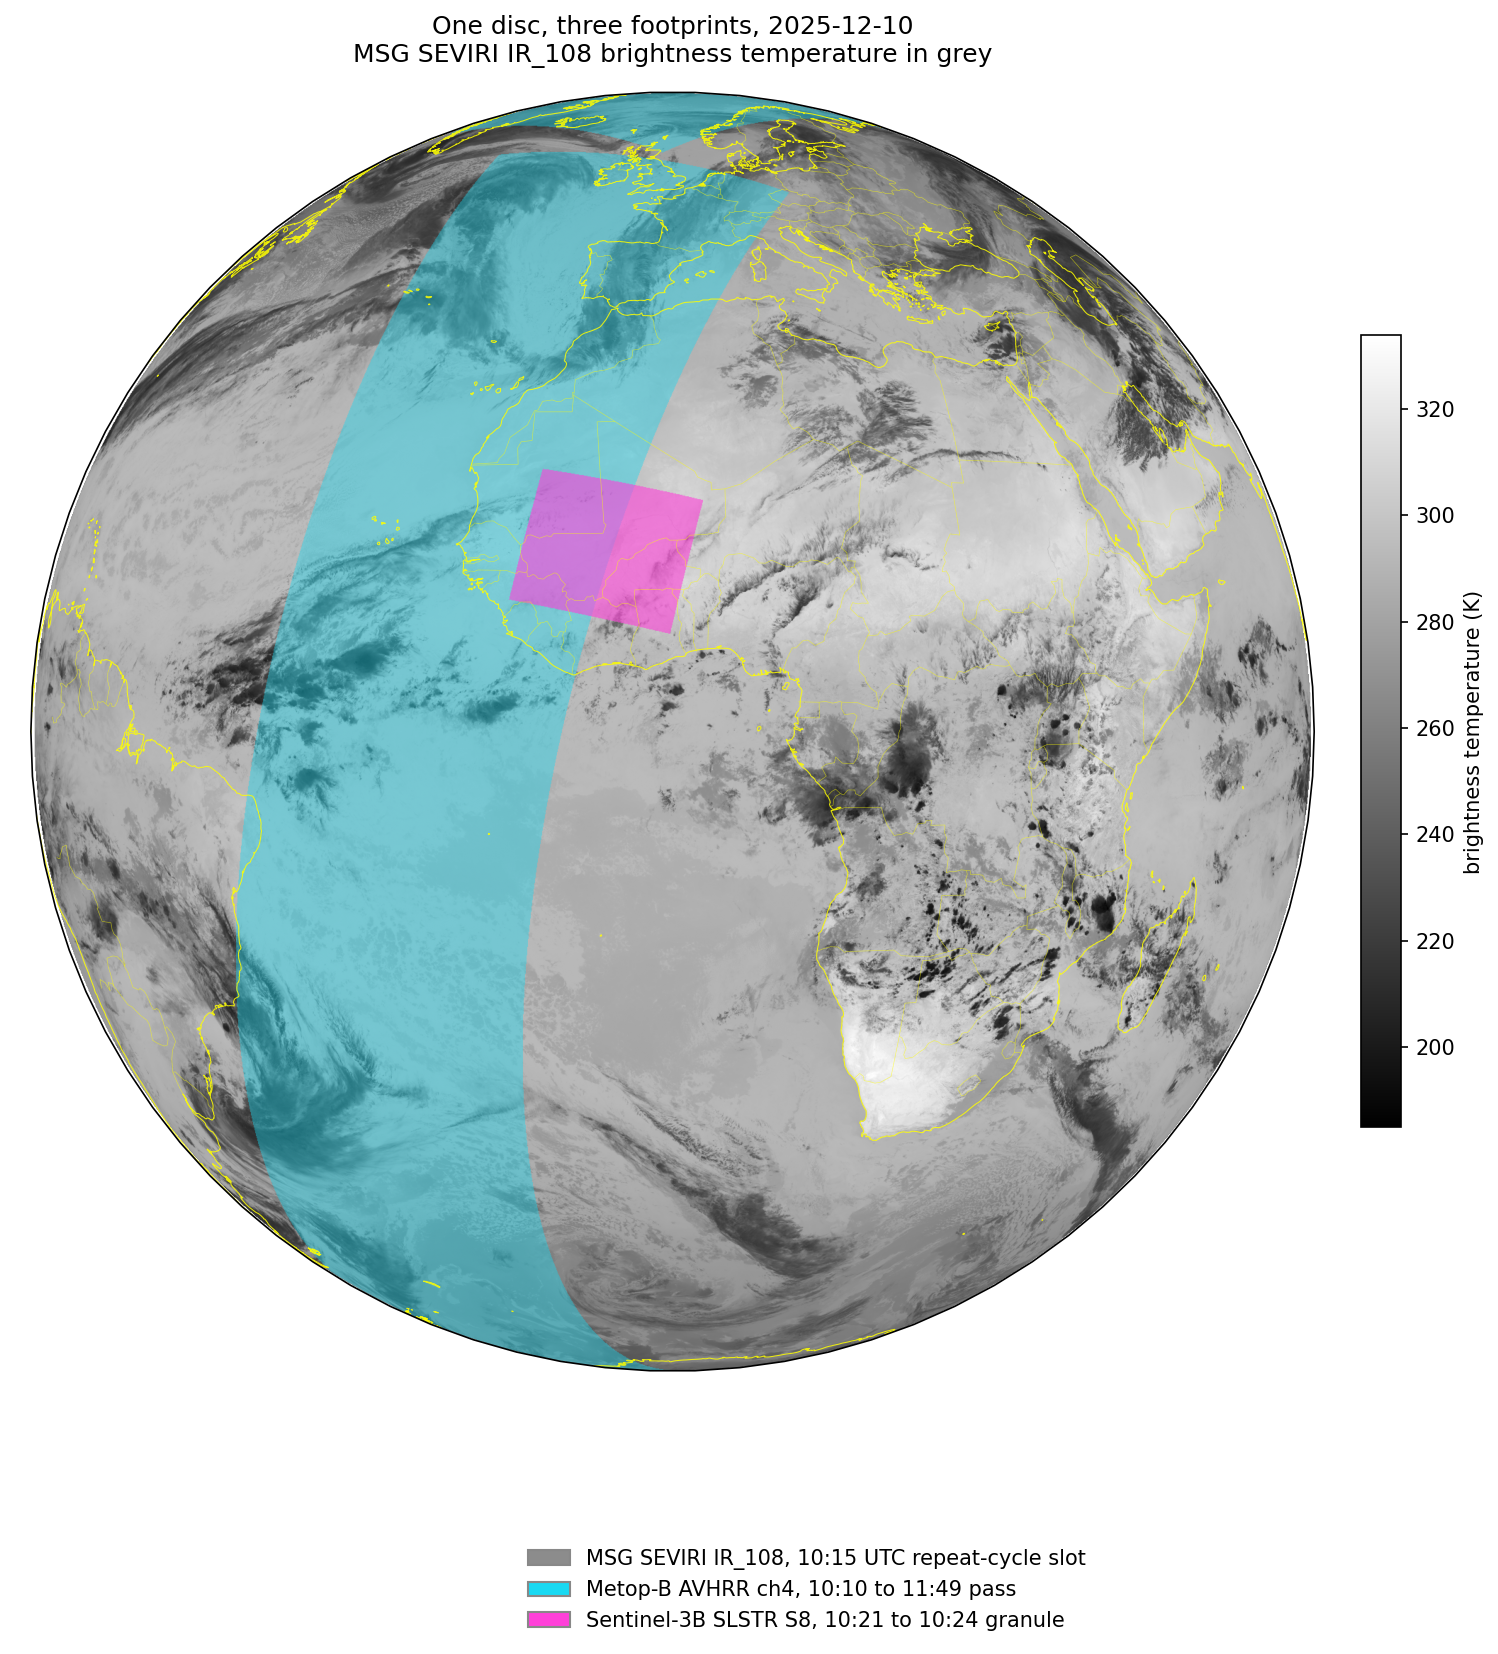

In [17]:
# The same three products without their crops: the disc and the orbit kept from the first
# read, and the SLSTR granule. The cropped cubes above are no longer needed, and
# release_read_handles hands the memory they held back to the operating system.
from defair_data import release_read_handles

del cube, cube_geos, cube3, cube_strict
release_read_handles()
# A footprint needs presence, not full resolution: every second AVHRR line and pixel is still
# finer than the 3 km SEVIRI grid it lands on, and a quarter of the orbit to resample.
avhrr_footprint = avhrr_orbit.isel(y=slice(None, None, 2), x=slice(None, None, 2))

disc = msg_disc.transform(
    "alignment",
    datasets=[avhrr_footprint, slstr],
    reference_dataset=msg_disc,
    spatial_method="nearest",
    temporal_method="nearest",
    time_tolerance="10min",
    time_bounds="base",
)

# Computed once: the coverage figures and the plot below all read from this one result.
disc = disc.data.compute()
print(f"  dims      : {dict(disc.sizes)}")
print(f"  variables : {list(disc.data_vars)}")

# SEVIRI is the reference, so it covers the disc by definition; the other two are the question.
seviri = np.isfinite(np.asarray(viz.pick(disc, "IR_108")[1].isel(time=0).values, dtype=float))
for substring, label in SOURCES[1:]:
    field = np.asarray(viz.pick(disc, substring)[1].isel(time=0).values, dtype=float)
    print(f"  {label:18s} covers {(np.isfinite(field) & seviri).sum() / seviri.sum():6.1%} of the disc")

viz.show_disk_footprints(
    disc,
    base=("IR_108", "MSG SEVIRI IR_108, 10:15 UTC repeat-cycle slot"),
    overlays=[
        ("brightness_temperature_4", "#19d9f2", 0.42, "Metop-B AVHRR ch4, 10:10 to 11:49 pass"),
        ("S8_BT_in", "#ff40d9", 0.60, "Sentinel-3B SLSTR S8, 10:21 to 10:24 granule"),
    ],
    title="One disc, three footprints, 2025-12-10\nMSG SEVIRI IR_108 brightness temperature in grey",
    label="brightness temperature (K)",
    save=OUTPUT / "geo_leo_disc_footprints.png",
)


In [18]:
close_dask_client()
